In [65]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from yellowbrick.cluster import KElbowVisualizer
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering

---
## <u>Load Dataset</u>

In [66]:
wine_data = load_wine()
X = pd.DataFrame(wine_data.data)
y = wine_data.target

X.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


---
## <u>Scale</u>

- Always scale first (normalise) and then do pca (drop dimensions with leat variance)
- we can skip scaling only and only if data has <u>same units</u> among all feature or the data is <u>centered</u>

In [72]:
scaler = StandardScaler()
scaler.set_output(transform="pandas")
X_scaled = scaler.fit_transform(X)
X_scaled.head()

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


---
## <u>PCA</u>

- we cant randomly choose any number of n_components we want, cuz shredding off each dimension means we are throwing some part of the data (variance) away as well so n_components value should be choosed systematically

In [78]:
pca = PCA(n_components = 5)
pca.set_output(transform="pandas")
X_scaled_pca = pca.fit_transform(X_scaled)
variance_kept = pca.explained_variance_ratio_.sum() # shows how much variance we actually kept after pca, should be > 0.80
print(variance_kept)
X_scaled_pca.head()

0.8016229275554788


,pca0,pca1,pca2,pca3,pca4
0,3.316751,1.443463,-0.165739,-0.215631,0.693043
1,2.209465,-0.333393,-2.026457,-0.291358,-0.257655
2,2.516740,1.031151,0.982819,0.724902,-0.251033
3,3.757066,2.756372,-0.176192,0.567983,-0.311842
4,1.008908,0.869831,2.026688,-0.409766,0.298458


---
## <u>Visualize the final training data</u>

<Axes: xlabel='pca0', ylabel='pca3'>

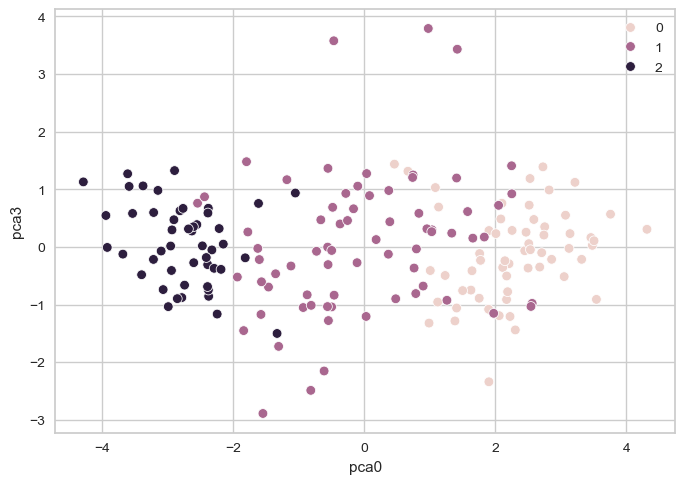

In [74]:
sns.scatterplot(
    x = X_scaled_pca.iloc[:,0],
    y = X_scaled_pca.iloc[:,3],
    hue=y
)

---
## <u>Finding K value</u>

- In hierarchial clustering, we will use a suggestive method (dendrogram) and a conclsive method (silhoutte score) to calculate k value
- we will not use knee/elbow method as that is preffered for k means clustering 

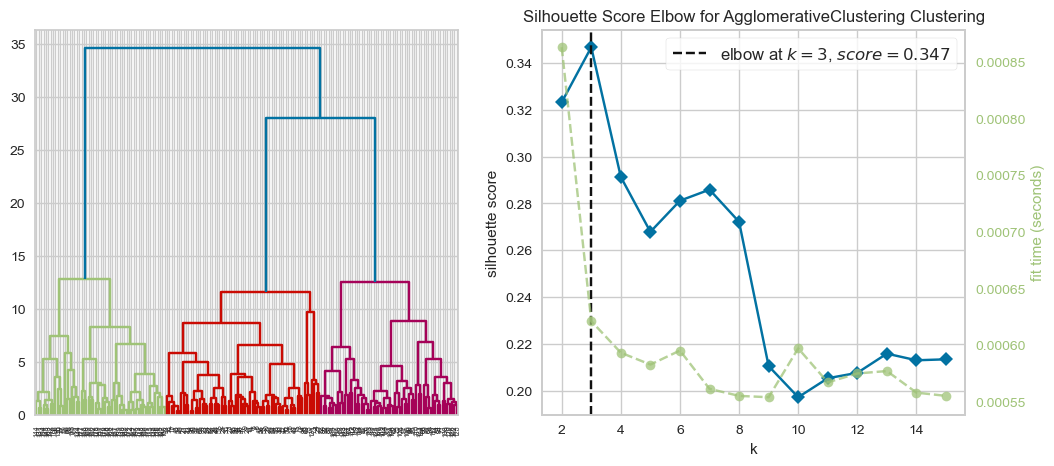

In [71]:
# define figure
fig, ax = plt.subplots(1,2,figsize=(12,5))

# Compute the hierarchical clustering linkage tree matrix and we dont need exact k values here unlike kmeans
z = linkage(X_scaled_pca,
            method="ward" # minimizes the total within cluster variance and compact/balanced/easy to interpret clusters.
) 

# create dendrogram
dendrogram(z,ax = ax[0]);

# we can find the silhoutte score with the KElbowVisualizer directly with just one small change
visualiser = KElbowVisualizer(
    AgglomerativeClustering(linkage = "ward"), 
    k = (2,16),
    metric='silhouette',                       # change metric to silhoutte score and keep everything same
    ax = ax[1]
)
visualiser.fit(X_scaled_pca)
visualiser.finalize()

plt.show()

# k = 3 clearly

---
## <u>Create Final Model</u>

Text(0.5, 1.0, 'Predicted clusters')

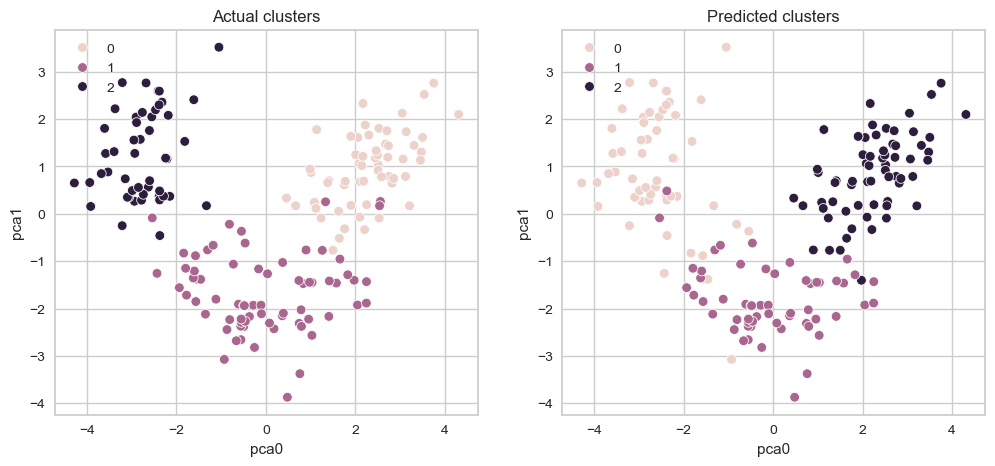

In [64]:
# make model
agg = AgglomerativeClustering(n_clusters=3)
labels = agg.fit_predict(X_scaled_pca)

# define figure
fig,ax = plt.subplots(1,2,figsize = (12,5))

# plot the graphs
sns.scatterplot(ax = ax[0],
                x=X_scaled_pca.iloc[:, 0],
                y=X_scaled_pca.iloc[:, 1],
                hue=y
)
sns.scatterplot(ax = ax[1],
                x=X_scaled_pca.iloc[:, 0],
                y=X_scaled_pca.iloc[:, 1],
                hue=labels
)

# put title on each graph
ax[0].set_title("Actual clusters")
ax[1].set_title("Predicted clusters")

Text(0.5, 1.0, 'DBSCAN on Noisy Moons')

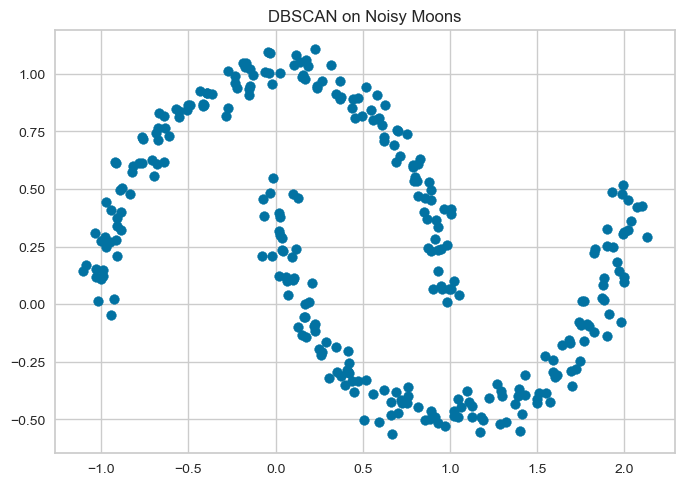

In [80]:
from sklearn.datasets import make_moons

# 1. Generate data with noise
X, y = make_moons(n_samples=300, noise=0.05, random_state=42)

plt.scatter(X[:, 0], X[:, 1])
# , c=labels, cmap='viridis', marker='o'
plt.title('DBSCAN on Noisy Moons')

AttributeError: PathCollection.set() got an unexpected keyword argument 'hue'

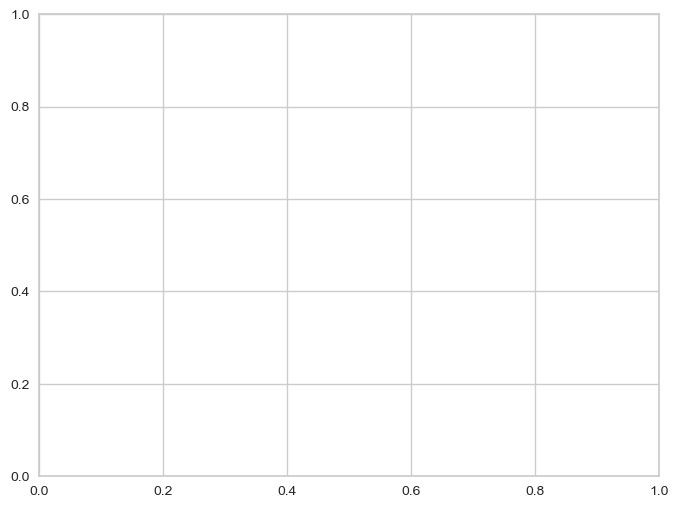

In [82]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Load and scale the real-life data
iris = load_iris()
X = StandardScaler().fit_transform(iris.data)

# 2. Reduce to 2D for visualization
X_pca = PCA(n_components=2).fit_transform(X)

# 3. Apply DBSCAN
# eps=0.45 and min_samples=5 works well on scaled Iris data
dbscan = DBSCAN(eps=0.45, min_samples=5)
labels = dbscan.fit_predict(X_pca)

# 4. Plot results
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], hue=labels)
plt.title("DBSCAN Clustering on Iris Dataset (PCA-Reduced)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(*scatter.legend_elements(), title="Clusters (-1 = Noise)")
